# SDSS Spectral Analysis - Classification Notebook

This notebook demonstrates how to analyze and classify astronomical objects (stars, galaxies, quasars) from the Sloan Digital Sky Survey (SDSS) dataset using machine learning.

## 1. Import Required Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2. Load and Explore the Dataset

In [18]:
# Load the dataset
df = pd.read_csv('./dataset/star_classification.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
for col in df.columns:
    print(f"  - {col}")

# Show first few rows
df.head()

Dataset Shape: (100000, 18)

Column Names:
  - obj_ID
  - alpha
  - delta
  - u
  - g
  - r
  - i
  - z
  - run_ID
  - rerun_ID
  - cam_col
  - field_ID
  - spec_obj_ID
  - class
  - redshift
  - plate
  - MJD
  - fiber_ID


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## 3. Dataset Overview and Class Distribution

Class Distribution:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

Percentage distribution:
class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: count, dtype: float64


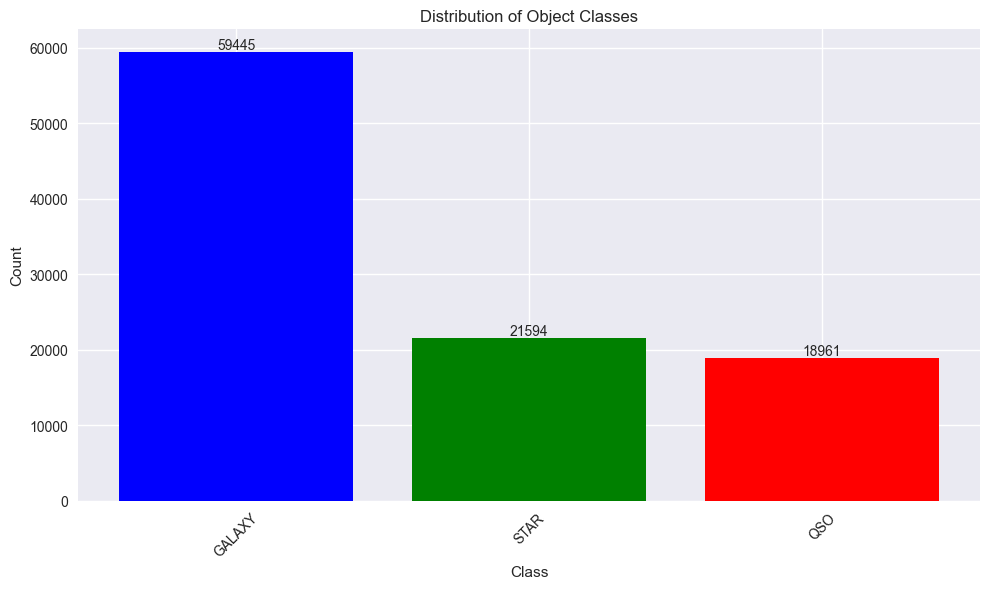

In [19]:
# Check class distribution
class_dist = df['class'].value_counts()
print("Class Distribution:")
print(class_dist)
print(f"\nPercentage distribution:")
print((class_dist / len(df)) * 100)

# Visualize class distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(class_dist.index, class_dist.values, color=['blue', 'green', 'red'])
plt.title('Distribution of Object Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 4. Feature Analysis

In [20]:
# Select numerical features for analysis
numerical_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 
                     'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 
                     'redshift', 'plate', 'MJD', 'fiber_ID']

# Check for missing values
print("Missing Values per Column:")
missing_values = df[numerical_features].isnull().sum()
print(missing_values)

# Basic statistics
print("\nBasic Statistics for Numerical Features:")
df[numerical_features].describe()

Missing Values per Column:
alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
run_ID      0
rerun_ID    0
cam_col     0
field_ID    0
redshift    0
plate       0
MJD         0
fiber_ID    0
dtype: int64

Basic Statistics for Numerical Features:


,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,0.576661,5137.009660,55588.647500,449.312740
std,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,0.730707,2952.303351,1808.484233,272.498404
min,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,-0.009971,266.000000,51608.000000,1.000000
25%,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,0.054517,2526.000000,54234.000000,221.000000
50%,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,0.424173,4987.000000,55868.500000,433.000000
75%,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,0.704154,7400.250000,56777.000000,645.000000
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,7.011245,12547.000000,58932.000000,1000.000000


## 5. Correlation Analysis

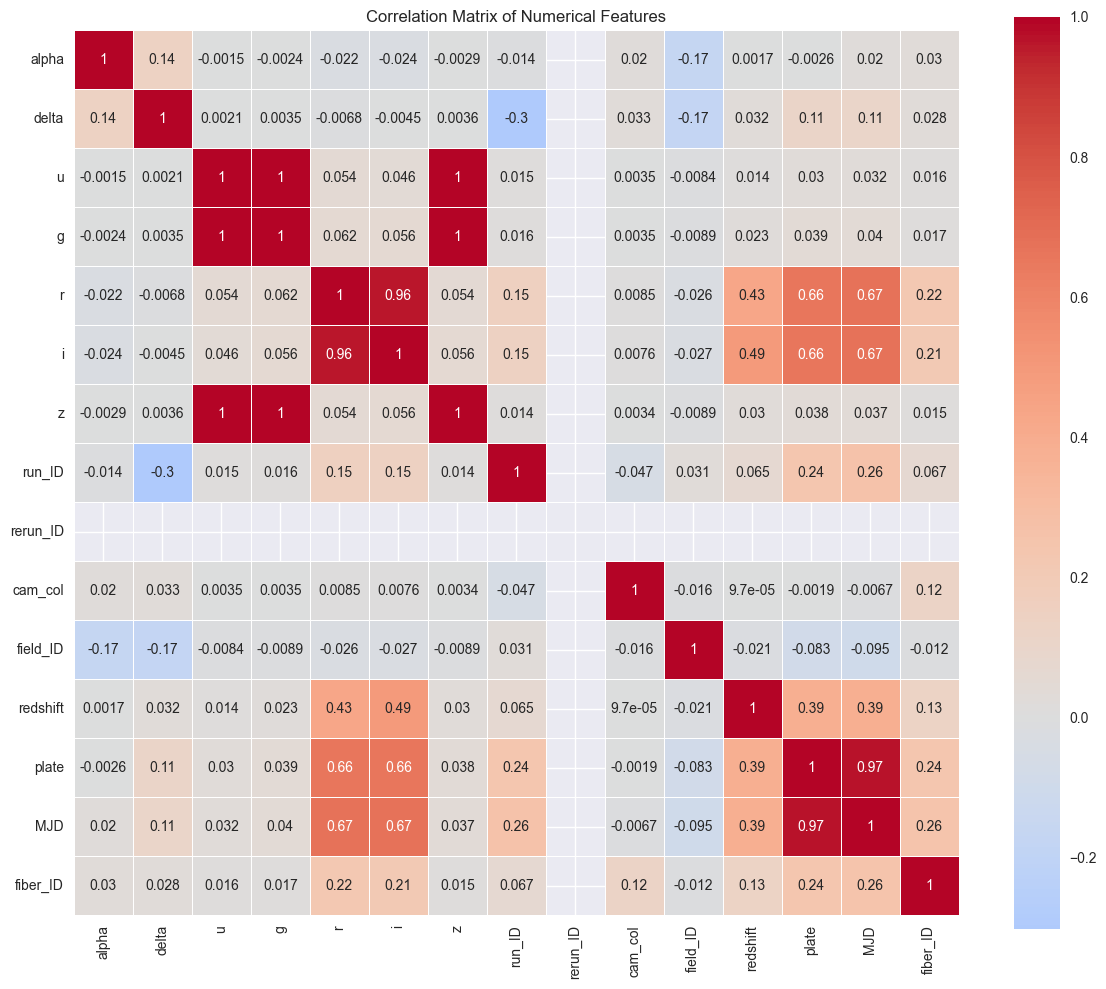

In [21]:
# Calculate correlation matrix
corr_matrix = df[numerical_features].corr()

# Plot correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 6. Feature Distributions by Class

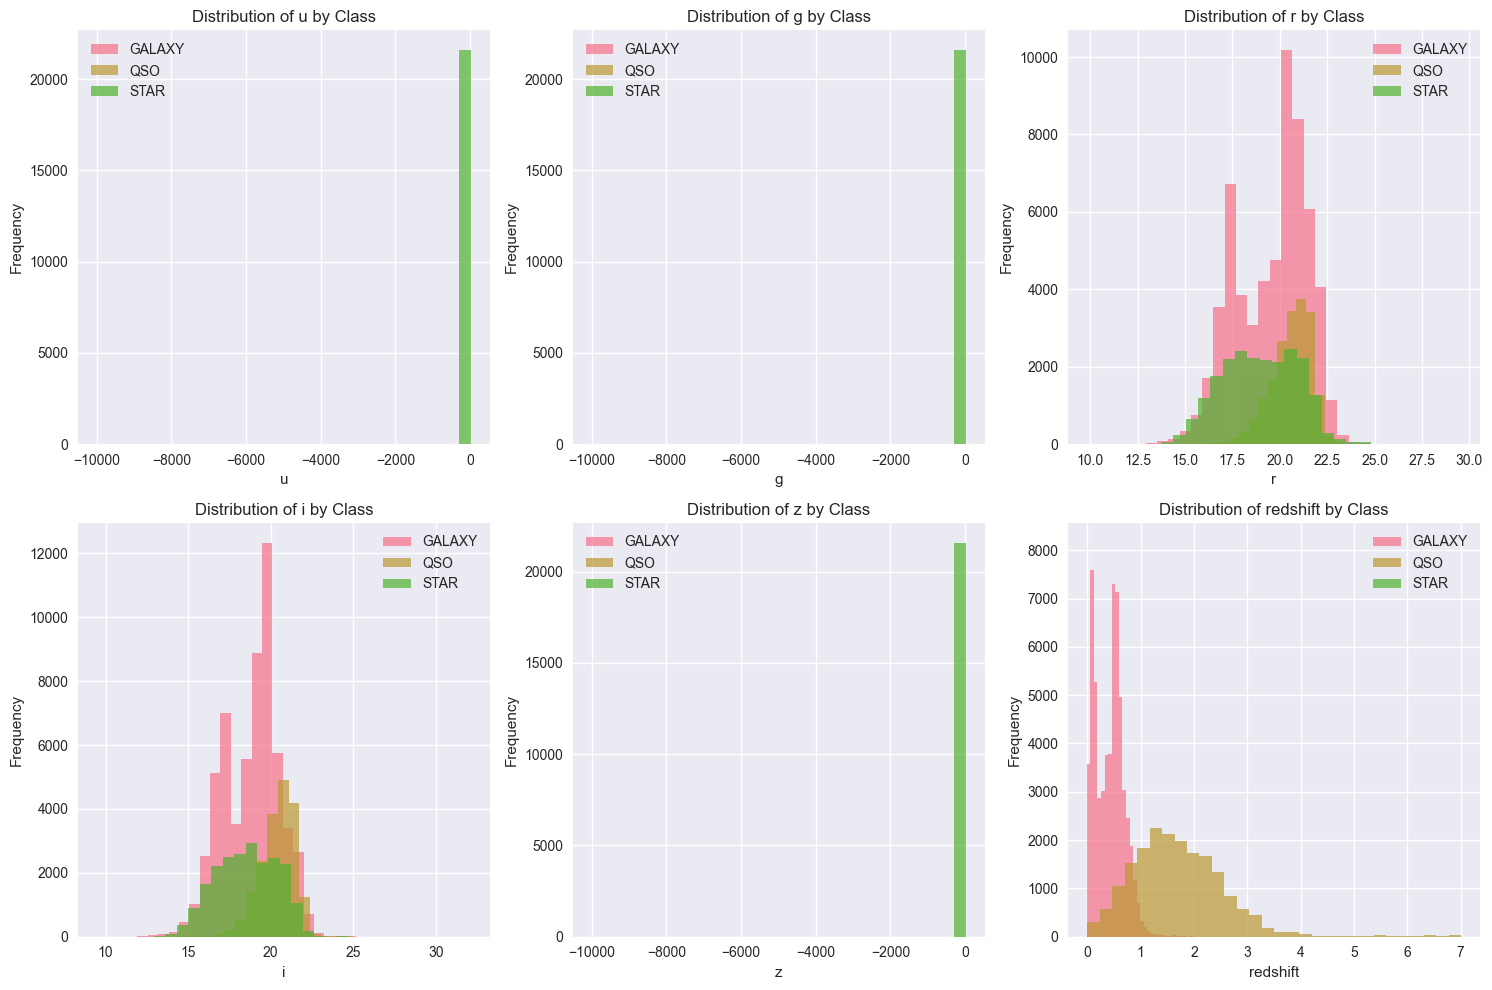

In [22]:
# Plot distributions of key features by class
key_features = ['u', 'g', 'r', 'i', 'z', 'redshift']
n_features = len(key_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, feature in enumerate(key_features):
    ax = axes[i]
    for class_name in df['class'].unique():
        data = df[df['class'] == class_name][feature]
        ax.hist(data, alpha=0.7, label=class_name, bins=30)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature} by Class')
    ax.legend()

# Hide empty subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Prepare Data for Modeling

In [23]:
# Prepare features and target
feature_columns = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 
                  'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 
                  'redshift', 'plate', 'MJD', 'fiber_ID']

X = df[feature_columns]
y = df['class']

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Encoded target values: {np.unique(y_encoded)}")
print(f"Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Features shape: (100000, 15)
Target shape: (100000,)
Encoded target values: [0 1 2]
Class mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


## 8. Train-Test Split and Scaling

In [24]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (80000, 15)
Test set shape: (20000, 15)


## 9. Train Random Forest Model

In [25]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9758


## 10. Model Evaluation

In [26]:
# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Cross-validation
cv_scores = cross_val_score(rf_model, X_test_scaled, y_test, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.98      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000


Cross-validation scores: [0.97075 0.978   0.97475 0.97175 0.97575]
Mean CV accuracy: 0.9742 (+/- 0.0053)


## 10b. Full Test Set — Per-Row Predictions

Every row in the held-out test split with true label, prediction, softmax confidence (`max` over classes), whether it matches reality, plus a compact view of mistakes (sorted so high-confidence errors appear first).


In [27]:
from IPython.display import display

# Evaluate every held-out test row (same predictions as above, tabulated here)
test_proba = rf_model.predict_proba(X_test_scaled)
test_results = pd.DataFrame(
    {
        "true_label": label_encoder.inverse_transform(y_test),
        "predicted_label": label_encoder.inverse_transform(y_pred),
        "confidence": test_proba.max(axis=1),
    }
)
test_results["correct"] = test_results["true_label"] == test_results["predicted_label"]

n = len(test_results)
n_ok = int(test_results["correct"].sum())

print(f"Full test set: {n} samples")
print(f"Accuracy: {n_ok / n:.6f}  ({n_ok} correct, {n - n_ok} incorrect)\n")

by_true = test_results.groupby("true_label").agg(samples=("correct", "size"), correct=("correct", "sum"))
by_true["accuracy"] = by_true["correct"] / by_true["samples"]
print("Per true class:")
print(by_true.to_string())

print("\nAll test-set predictions:")
display(test_results.reset_index(drop=True))

wrong = test_results[~test_results["correct"]]
print(f"\nMisclassified ({len(wrong)} rows):")
display(wrong.sort_values("confidence", ascending=False))

Full test set: 20000 samples
Accuracy: 0.975850  (19517 correct, 483 incorrect)

Per true class:
            samples  correct  accuracy
true_label                            
GALAXY        11889    11686  0.982925
QSO            3792     3515  0.926951
STAR           4319     4316  0.999305

All test-set predictions:


,true_label,predicted_label,confidence,correct
0,STAR,STAR,0.882959,True
1,GALAXY,GALAXY,0.949665,True
2,GALAXY,GALAXY,0.577714,True
3,GALAXY,GALAXY,0.986879,True
4,GALAXY,GALAXY,0.987587,True
...,...,...,...,...
19995,GALAXY,GALAXY,0.941554,True
19996,GALAXY,GALAXY,0.989166,True
19997,GALAXY,GALAXY,0.989287,True
19998,GALAXY,GALAXY,0.984818,True



Misclassified (483 rows):


,true_label,predicted_label,confidence,correct
9426,QSO,GALAXY,0.988690,False
1068,QSO,GALAXY,0.988586,False
864,QSO,GALAXY,0.988348,False
9171,QSO,GALAXY,0.988331,False
11676,QSO,GALAXY,0.988316,False
...,...,...,...,...
11296,GALAXY,STAR,0.473144,False
6110,QSO,GALAXY,0.468392,False
4816,GALAXY,STAR,0.466135,False
1130,GALAXY,QSO,0.464443,False


## 11. Confusion Matrix

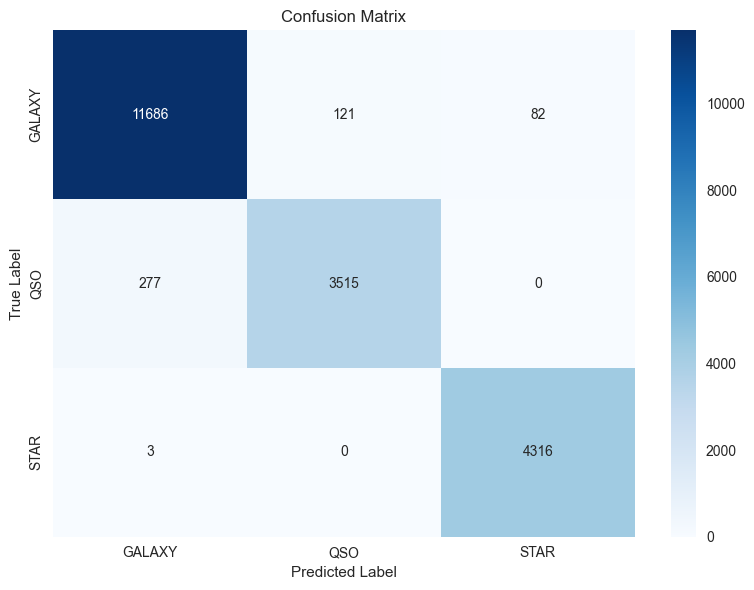

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 11b. Results Visualization (confusion matrix, F1, precision, recall)

Side-by-side confusion matrices (raw counts and row-normalized by true class) plus per-class **precision**, **recall**, and **F1**, with **macro** and **weighted** F1 reference lines.

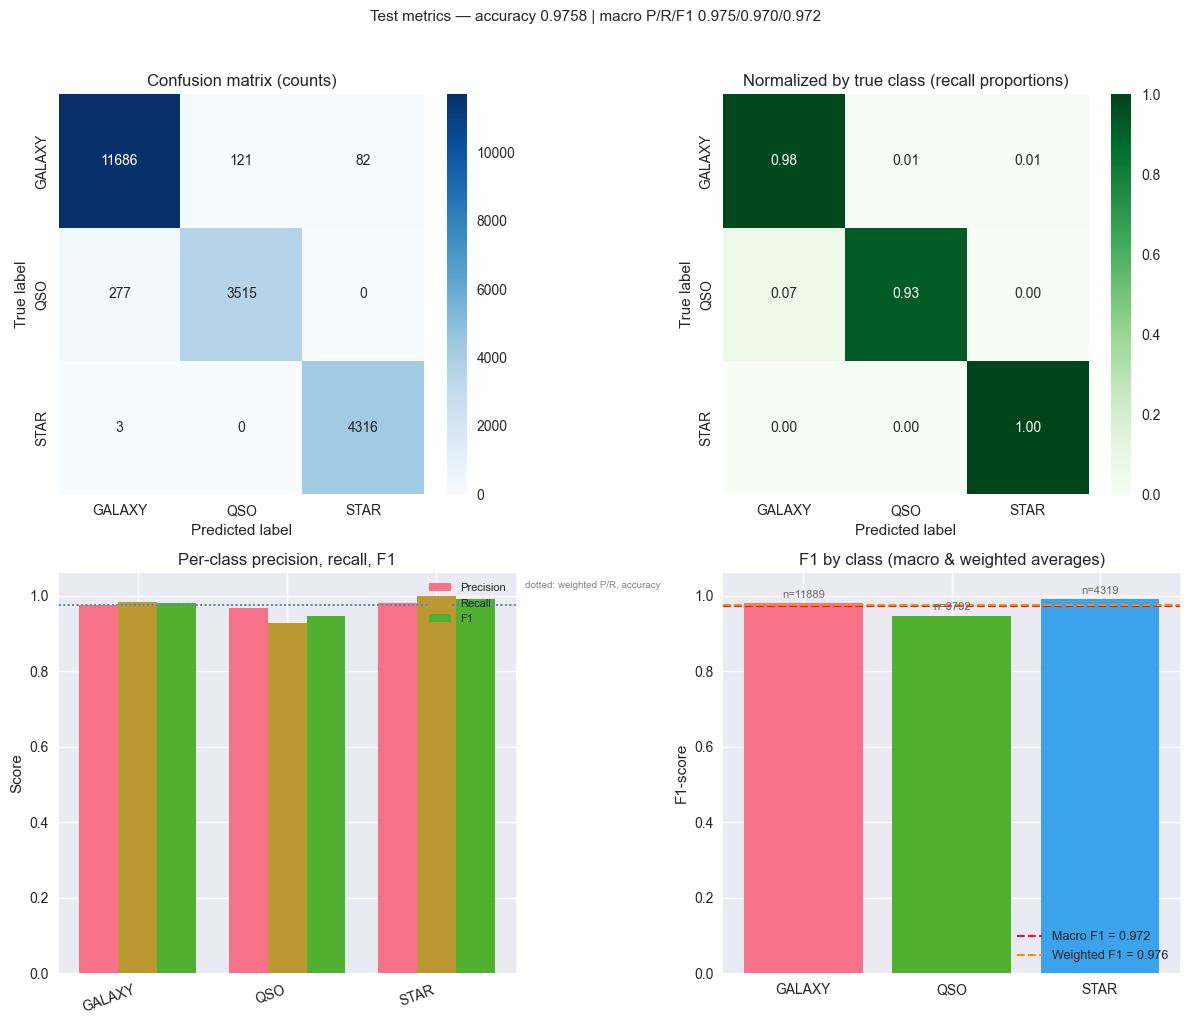

Per-class and average metrics:

              precision  recall      f1  support
GALAXY           0.9766  0.9829  0.9798  11889.0
QSO              0.9667  0.9270  0.9464   3792.0
STAR             0.9814  0.9993  0.9902   4319.0
macro avg        0.9749  0.9697  0.9721  20000.0
weighted avg     0.9758  0.9758  0.9757  20000.0


In [29]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

class_names = list(label_encoder.classes_)
labels = np.arange(len(class_names))
cm_counts = confusion_matrix(y_test, y_pred, labels=labels)

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels, average=None, zero_division=0
)

report = classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0
)
macro_f1 = report["macro avg"]["f1-score"]
weighted_f1 = report["weighted avg"]["f1-score"]
macro_p = report["macro avg"]["precision"]
macro_r = report["macro avg"]["recall"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Counts
sns.heatmap(
    cm_counts,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Confusion matrix (counts)")
axes[0, 0].set_ylabel("True label")
axes[0, 0].set_xlabel("Predicted label")

# Row-normalized
row_tot = cm_counts.sum(axis=1, keepdims=True).astype(float)
cm_norm = np.divide(
    cm_counts.astype(float),
    row_tot,
    out=np.zeros_like(cm_counts, dtype=float),
    where=(row_tot > 0),
)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Normalized by true class (recall proportions)")
axes[0, 1].set_ylabel("True label")
axes[0, 1].set_xlabel("Predicted label")

# Grouped precision / recall / F1
ax_mid = axes[1, 0]
x_idx = np.arange(len(class_names))
bar_w = 0.26
ax_mid.bar(x_idx - bar_w, precision, bar_w, label="Precision")
ax_mid.bar(x_idx, recall, bar_w, label="Recall")
ax_mid.bar(x_idx + bar_w, f1, bar_w, label="F1")
ax_mid.axhline(report["weighted avg"]["precision"], color="slategray", ls=":", lw=1.2)
ax_mid.axhline(report["weighted avg"]["recall"], color="darkgray", ls=":", lw=1.2)
acc_test = rf_model.score(X_test_scaled, y_test)
ax_mid.axhline(acc_test, color="steelblue", ls=":", lw=1.2)
ax_mid.set_xticks(x_idx)
ax_mid.set_xticklabels(class_names, rotation=20, ha="right")
ax_mid.set_ylim(0, 1.06)
ax_mid.set_ylabel("Score")
ax_mid.set_title("Per-class precision, recall, F1")
ax_mid.legend(loc="upper right", fontsize=8)
ax_mid.text(
    1.02,
    0.98,
    "dotted: weighted P/R, accuracy",
    transform=ax_mid.transAxes,
    fontsize=7,
    va="top",
    ha="left",
    color="gray",
)

# F1 with macro / weighted
ax_f1 = axes[1, 1]
ax_f1.bar(class_names, f1, color=sns.color_palette("husl", len(class_names)))
ax_f1.axhline(macro_f1, color="crimson", ls="--", lw=1.5, label=f"Macro F1 = {macro_f1:.3f}")
ax_f1.axhline(weighted_f1, color="darkorange", ls="--", lw=1.5, label=f"Weighted F1 = {weighted_f1:.3f}")
ax_f1.set_ylim(0, 1.06)
ax_f1.set_ylabel("F1-score")
ax_f1.set_title("F1 by class (macro & weighted averages)")
ax_f1.legend(loc="lower right", fontsize=9)
for i, (s, fv) in enumerate(zip(support, f1)):
    ax_f1.annotate(f"n={s}", xy=(i, fv), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8, color="dimgray")

plt.suptitle(
    f"Test metrics — accuracy {accuracy_score(y_test, y_pred):.4f} | macro P/R/F1 {macro_p:.3f}/{macro_r:.3f}/{macro_f1:.3f}",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()
plt.show()

summary_table = pd.DataFrame(
    {"precision": precision, "recall": recall, "f1": f1, "support": support},
    index=class_names,
)
summary_table.loc["macro avg"] = [macro_p, macro_r, macro_f1, support.sum()]
summary_table.loc["weighted avg"] = [
    report["weighted avg"]["precision"],
    report["weighted avg"]["recall"],
    report["weighted avg"]["f1-score"],
    support.sum(),
]
print("Per-class and average metrics:\n")
print(summary_table.round(4).to_string())

## 11c. Misclassification analysis — where the model errs and plausible causes

Mislabelled rows are summarized by **(true → predicted)** pair, then correlated with astronomy-aware features (colour and **redshift**). Overlap in magnitude–colour–redshift space between classes and noisy or ambiguous observations are common explanations; the commentary below interprets typical SDSS separation limits (not causal proof).

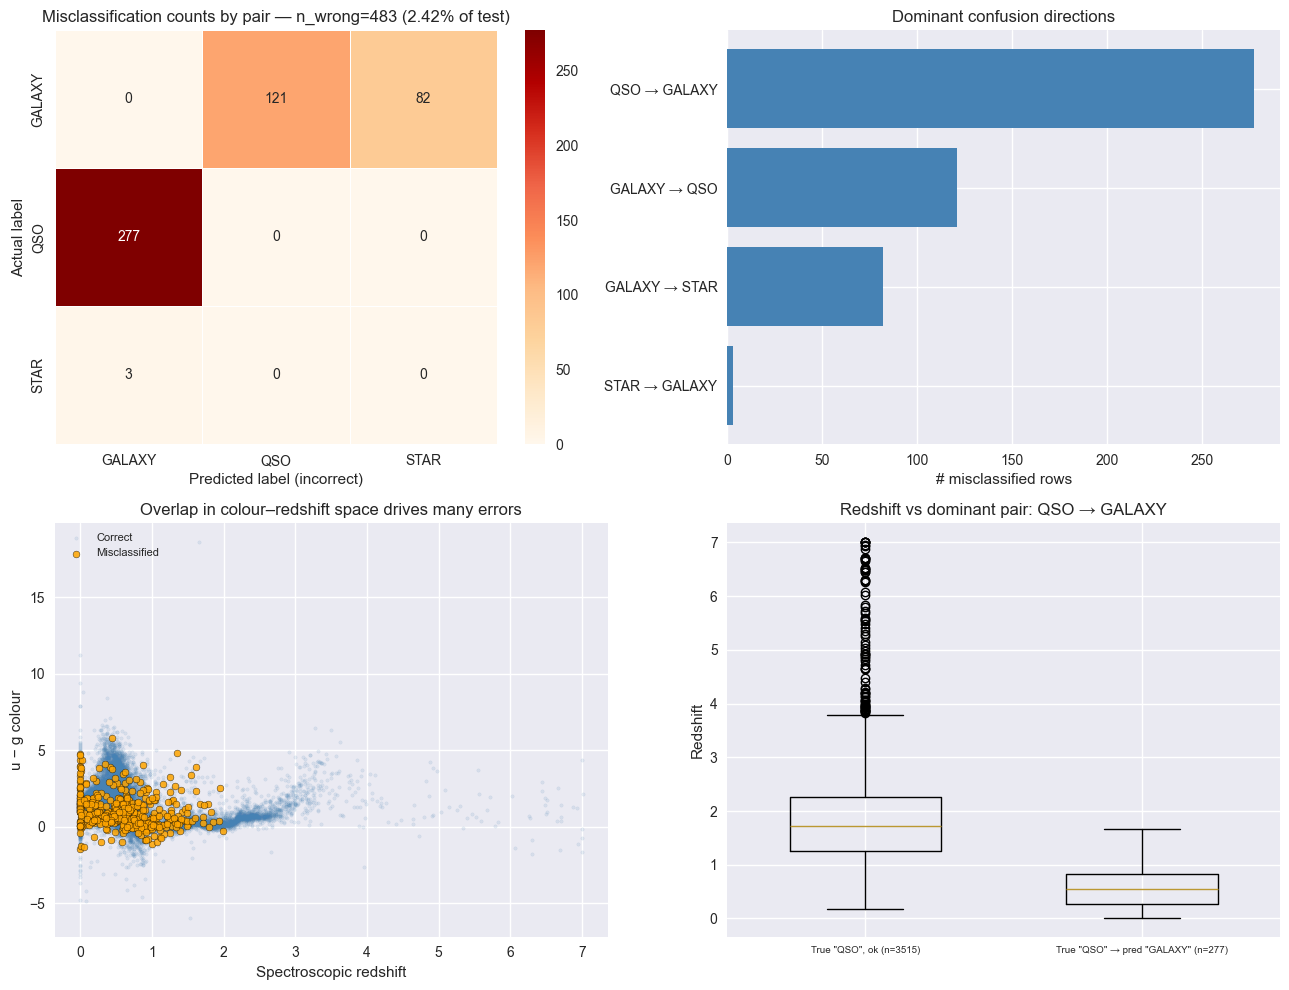

- **Dominant confusion** is `QSO → GALAXY` (~57% of all errors).
- **Compact/star-forming galaxies** can mimic point-like photometry near point sources; extinction and reddening widen overlap.
- Errors cluster where **colour–redshift manifolds** of different spectroscopic labels intersect — the plots above show dense orange points in those wedges.
- About **2.42%** of test rows disagree with the spectroscopic label. High **`confidence`** (`predict_proba` max) on wrong rows flags **boundary** objects the forest resolves too sharply.
- *Interpretation is heuristic*: use spectroscopic qualities, residuals, morphology, or spectra if you need to separate physics from catalogue noise.

In [30]:
from IPython.display import Markdown, display

true_lbl = label_encoder.inverse_transform(y_test).astype(str)
pred_lbl = label_encoder.inverse_transform(y_pred).astype(str)
wrong_mask = true_lbl != pred_lbl
n_err = int(wrong_mask.sum())
n_tot = len(wrong_mask)
err_rate = n_err / n_tot if n_tot else 0.0

errs_true = true_lbl[wrong_mask]
errs_pred = pred_lbl[wrong_mask]

if n_err == 0:
    display(
        Markdown(
            "No misclassifications on the test split — either a degenerate slice or rerun after training."
        )
    )
else:
    pair_counts = pd.crosstab(
        pd.Series(errs_true, name="True class"),
        pd.Series(errs_pred, name="Mis-predicted as"),
    )

    Xt = X_test.reset_index(drop=True)
    redshift = Xt["redshift"].to_numpy(dtype=float)
    u_g = (Xt["u"] - Xt["g"]).to_numpy(dtype=float)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    sns.heatmap(pair_counts, annot=True, fmt="d", cmap="OrRd", linewidths=0.5, ax=axes[0, 0])
    axes[0, 0].set_title(
        f"Misclassification counts by pair — n_wrong={n_err} ({100 * err_rate:.2f}% of test)"
    )
    axes[0, 0].set_xlabel("Predicted label (incorrect)")
    axes[0, 0].set_ylabel("Actual label")

    pairs_long = []
    for t in pair_counts.index:
        for p in pair_counts.columns:
            c = int(pair_counts.loc[t, p])
            if c > 0:
                pairs_long.append((f"{t} → {p}", c))

    pairs_sorted = sorted(pairs_long, key=lambda x: -x[1])[:8]
    pairs_df = pd.DataFrame(pairs_sorted, columns=["pair", "count"])

    axb = axes[0, 1]
    axb.barh(pairs_df["pair"], pairs_df["count"], color="steelblue")
    axb.invert_yaxis()
    axb.set_xlabel("# misclassified rows")
    axb.set_title("Dominant confusion directions")

    ax_sc = axes[1, 0]
    ax_sc.scatter(
        redshift[~wrong_mask],
        u_g[~wrong_mask],
        s=6,
        alpha=0.12,
        c="steelblue",
        label="Correct",
    )
    ax_sc.scatter(
        redshift[wrong_mask],
        u_g[wrong_mask],
        s=24,
        alpha=0.85,
        ec="black",
        lw=0.3,
        fc="orange",
        label="Misclassified",
    )
    ax_sc.set_xlabel("Spectroscopic redshift")
    ax_sc.set_ylabel("u − g colour")
    ax_sc.set_title("Overlap in colour–redshift space drives many errors")
    ax_sc.legend(loc="upper left", fontsize=8)

    top_pair_label = pairs_df.iloc[0]["pair"]
    t_lab, p_lab = top_pair_label.split(" → ")
    mask_pair = wrong_mask & (true_lbl == t_lab) & (pred_lbl == p_lab)
    mask_same_true_correct = (~wrong_mask) & (true_lbl == t_lab)

    ax_box = axes[1, 1]
    data_for_box = []
    labels_for_box = []

    if mask_pair.any() and mask_same_true_correct.any():
        data_for_box = [redshift[mask_same_true_correct], redshift[mask_pair]]
        labels_for_box = [
            f'True "{t_lab}", ok (n={int(mask_same_true_correct.sum())})',
            f'True "{t_lab}" → pred "{p_lab}" (n={int(mask_pair.sum())})',
        ]
    elif mask_pair.any():
        data_for_box = [redshift[mask_pair]]
        labels_for_box = [f'True "{t_lab}" → "{p_lab}"']

    if data_for_box:
        ax_box.boxplot(data_for_box, tick_labels=labels_for_box, widths=0.55)
        ax_box.set_ylabel("Redshift")
        ax_box.set_title(f"Redshift vs dominant pair: {top_pair_label}")
    else:
        ax_box.text(
            0.5,
            0.5,
            "No groups for pairwise redshift boxes",
            ha="center",
            va="center",
            transform=ax_box.transAxes,
        )

    ax_box.tick_params(axis="x", labelsize=7)
    plt.tight_layout()
    plt.show()

    explain = []

    busiest = pairs_df.iloc[0]
    frac_busy = busiest["count"] / max(n_err, 1) * 100
    explain.append(
        f"**Dominant confusion** is `{busiest['pair']}` (~{frac_busy:.0f}% of all errors)."
    )
    pair_slug = busiest["pair"]
    if "STAR" in pair_slug.upper() and "QSO" in pair_slug.upper():
        explain.append(
            "Stars and quasars can share **blue optical colours**; without PSF-shape or spectra, RF only sees overlaps in **ugriz + redshift**."
        )
    if "GALAXY" in pair_slug.upper():
        explain.append(
            "**Compact/star-forming galaxies** can mimic point-like photometry near point sources; extinction and reddening widen overlap."
        )
    explain.append(
        "Errors cluster where **colour–redshift manifolds** of different spectroscopic labels intersect — the plots above show dense orange points in those wedges."
    )
    mist_pct = (1.0 - accuracy_score(y_test, y_pred)) * 100
    explain.append(
        f"About **{mist_pct:.2f}%** of test rows disagree with the spectroscopic label. "
        "High **`confidence`** (`predict_proba` max) on wrong rows flags **boundary** objects the forest resolves too sharply."
    )
    explain.append(
        "*Interpretation is heuristic*: use spectroscopic qualities, residuals, morphology, or spectra if you need to separate physics from catalogue noise."
    )

    display(Markdown("\n".join(f"- {e}" for e in explain)))



## 12. Feature Importance

Feature Importance:
     feature  importance
11  redshift    0.597125
6          z    0.089169
3          g    0.063883
2          u    0.059908
5          i    0.055414
12     plate    0.044944
4          r    0.035010
13       MJD    0.030925
0      alpha    0.006600
1      delta    0.005988
7     run_ID    0.004925
14  fiber_ID    0.002693
10  field_ID    0.002682
9    cam_col    0.000733
8   rerun_ID    0.000000


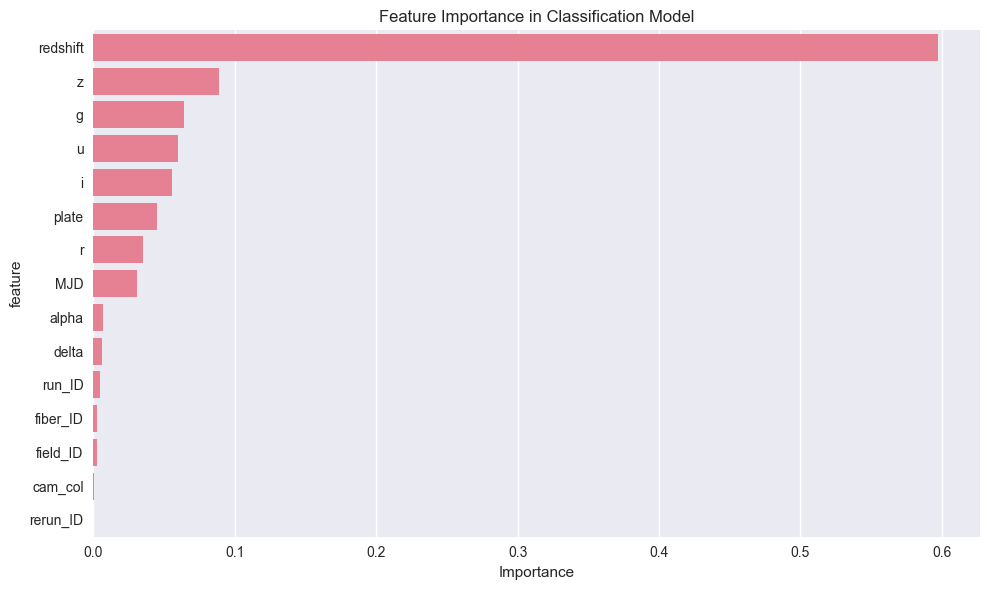

In [31]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance in Classification Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 13. Model Performance Summary

In [32]:
print("=== MODEL PERFORMANCE SUMMARY ===")
print(f"Dataset size: {len(df)} observations")
print(f"Number of features: {len(feature_columns)}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Classes: {list(label_encoder.classes_)}")
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Cross-validation mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\nTop 5 Most Important Features:")
for i, row in feature_importance.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

=== MODEL PERFORMANCE SUMMARY ===
Dataset size: 100000 observations
Number of features: 15
Number of classes: 3
Classes: ['GALAXY', 'QSO', 'STAR']
Model Accuracy: 0.9758
Cross-validation mean: 0.9742 (+/- 0.0053)

Top 5 Most Important Features:
  redshift: 0.5971
  z: 0.0892
  g: 0.0639
  u: 0.0599
  i: 0.0554


## 14. Prediction Example

In [33]:
# Example prediction on a new sample
sample_data = X_test_scaled[0].reshape(1, -1)
prediction = rf_model.predict(sample_data)
prediction_proba = rf_model.predict_proba(sample_data)

predicted_class = label_encoder.inverse_transform(prediction)[0]
print(f"Predicted class: {predicted_class}")
print(f"Prediction probabilities:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name}: {prediction_proba[0][i]:.4f}")

Predicted class: STAR
Prediction probabilities:
  GALAXY: 0.0514
  QSO: 0.0657
  STAR: 0.8830


## Summary

This notebook demonstrates:

1. **Data Loading and Exploration**: Loading the SDSS dataset and understanding its structure
2. **Class Distribution Analysis**: Understanding the balance of star, galaxy, and quasar classes
3. **Feature Analysis**: Examining numerical features and their relationships
4. **Model Training**: Using Random Forest for multiclass classification
5. **Model Evaluation**: Accuracy, cross-validation, and confusion matrix
6. **Feature Importance**: Identifying which features are most predictive

The approach successfully classifies astronomical objects with good accuracy, making it suitable for real-world SDSS data analysis.